# GHaLIB غالب: Generating Hope and Linguistic Irony in Banter

### **Setting Modules**

In [1]:
!git clone https://github.com/urduhack/urduhack.git

Cloning into 'urduhack'...
remote: Enumerating objects: 1432, done.
remote: Counting objects: 100% (24/24), done.
remote: Compressing objects: 100% (22/22), done.
remote: Total 1432 (delta 2), reused 5 (delta 2), pack-reused 1408 (from 1)
Receiving objects: 100% (1432/1432), 496.64 KiB | 5.02 MiB/s, done.
Resolving deltas: 100% (801/801), done.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from transformers import AutoModel, AutoTokenizer
from typing import FrozenSet
from wordcloud import WordCloud
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from transformers import RobertaTokenizer, RobertaModel
from tqdm import tqdm
import lightgbm as lgb
from sklearn.preprocessing import LabelEncoder
import warnings
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score

warnings.filterwarnings("ignore", message="Some weights of RobertaModel were not initialized from the model checkpoint")

### **Text Preprocessing**

In [2]:
STOP_WORDS: FrozenSet[str] = frozenset("""

 آ آئی آئیں آئے آتا آتی آتے آس آمدید آنا آنسہ آنی آنے آپ آگے آہ آہا آیا اب ابھی ابے
 ارے اس اسکا اسکی اسکے اسی اسے اف افوہ البتہ الف ان اندر انکا انکی انکے انہوں انہی انہیں اوئے اور اوپر
 اوہو اپ اپنا اپنوں اپنی اپنے اپنےآپ اکثر اگر اگرچہ اہاہا ایسا ایسی ایسے ایک بائیں بار بارے بالکل باوجود باہر
 بج بجے بخیر بشرطیکہ بعد بعض بغیر بلکہ بن بنا بناؤ بند بڑی بھر بھریں بھی بہت بہتر تاکہ تاہم تب تجھ
 تجھی تجھے ترا تری تلک تم تمام تمہارا تمہاروں تمہاری تمہارے تمہیں تو تک تھا تھی تھیں تھے تیرا تیری تیرے
 جا جاؤ جائیں جائے جاتا جاتی جاتے جانی جانے جب جبکہ جدھر جس جسے جن جناب جنہوں جنہیں جو جہاں جی جیسا
 جیسوں جیسی جیسے حالانکہ حالاں حصہ حضرت خاطر خالی خواہ خوب خود دائیں درمیان دریں دو دوران دوسرا دوسروں دوسری دوں
 دکھائیں دی دیئے دیا دیتا دیتی دیتے دیر دینا دینی دینے دیکھو دیں دیے دے ذریعے رکھا رکھتا رکھتی رکھتے رکھنا رکھنی
 رکھنے رکھو رکھی رکھے رہ رہا رہتا رہتی رہتے رہنا رہنی رہنے رہو رہی رہیں رہے ساتھ سامنے ساڑھے سب سبھی
 سراسر سمیت سوا سوائے سکا سکتا سکتے سہ سہی سی سے شاید شکریہ صاحب صاحبہ صرف ضرور طرح طرف طور علاوہ عین
 فقط فلاں فی قبل قطا لئے لائی لائے لاتا لاتی لاتے لانا لانی لانے لایا لو لوجی لوگوں لگ لگا لگتا
 لگتی لگی لگیں لگے لہذا لی لیا لیتا لیتی لیتے لیکن لیں لیے لے ماسوا مت مجھ مجھی مجھے محترم محترمہ محض
 مرا مرحبا مری مرے مزید مس مسز مسٹر مطابق مل مکرمی مگر مگھر مہربانی میرا میروں میری میرے میں نا نزدیک
 نما نہ نہیں نیز نیچے نے و وار واسطے واقعی والا والوں والی والے واہ وجہ ورنہ وغیرہ ولے وگرنہ وہ وہاں
 وہی وہیں ویسا ویسے ویں پاس پایا پر پس پلیز پون پونی پونے پھر پہ پہلا پہلی پہلے پیر پیچھے چاہئے
 چاہتے چاہیئے چاہے چلا چلو چلیں چلے چناچہ چند چونکہ چکی چکیں چکے ڈالنا ڈالنی ڈالنے ڈالے کئے کا کاش کب کبھی
 کدھر کر کرتا کرتی کرتے کرم کرنا کرنے کرو کریں کرے کس کسی کسے کم کن کنہیں کو کوئی کون کونسا
 کونسے کچھ کہ کہا کہاں کہہ کہی کہیں کہے کی کیا کیسا کیسے کیونکر کیونکہ کیوں کیے کے گئی گئے گا گنا
 گو گویا گی گیا ہائیں ہائے ہاں ہر ہرچند ہرگز ہم ہمارا ہماری ہمارے ہمی ہمیں ہو ہوئی ہوئیں ہوئے ہوا
 ہوبہو ہوتا ہوتی ہوتیں ہوتے ہونا ہونگے ہونی ہونے ہوں ہی ہیلو ہیں ہے یا یات یعنی یک یہ یہاں یہی یہیں
""".split())

def remove_stopwords(text: str) -> str:
    return " ".join(word for word in text.split() if word not in STOP_WORDS)

In [3]:
def clean_urdu_text(text):
    text = re.sub(r"[ًٌٍَُِّْ]", "", text)
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    text = remove_stopwords(text)
    return text


def clean_english_text(text):

    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r'[^\x00-\x7F]+', '', text)  
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"\s+", " ", text).strip()
    words = text.split()
    stopwords_ = stopwords.words('english')
    stopwords_ = stopwords_ + ['user', 'br']
    words = [word for word in words if word not in stopwords_]

    return " ".join(words)

In [4]:
text = "???یہ ایک مثال ہے"
print(clean_urdu_text(text))

text = "This is samplE TexT??"
print(clean_english_text(text))

مثال
sample text


### **Loading**

In [20]:
ur_train  = pd.read_csv('/kaggle/input/polyhope-iberlef-2025/Ur_train.csv')
ur_dev = pd.read_csv('/kaggle/input/polyhope-iberlef-2025/Ur_dev.csv')
ur_test = pd.read_csv('/kaggle/input/polyhope-iberlef-2025/Ur_test_without_labels.csv')

ur_train.head()

,text,binary,multiclass
0,#USER# پھیل گئی بالوں میں سپیدی چونک ذرا کروٹ ...,Not Hope,Not Hope
1,#خاتم_النبیین_محمدﷺ⁩سیشن: #شان_اولیاءِکرام_رحم...,Not Hope,Not Hope
2,ریوڑ بروں دنوں کی مہم کو خاموش کرنے کے کچھ واپ...,Not Hope,Not Hope
3,میں مانتا ہوں کہ مریم Woronov (مرڈوک کے سیکرٹر...,Not Hope,Not Hope
4,میں نے اس کی اصل کے طور پر تکلیف دہ طویل بس کے...,Not Hope,Not Hope


In [12]:
en_train  = pd.read_csv('/kaggle/input/polyhope-iberlef-2025/en_train.csv')
en_dev = pd.read_csv('/kaggle/input/polyhope-iberlef-2025/en_dev.csv')
en_test = pd.read_csv('/kaggle/input/polyhope-iberlef-2025/en_test_without_labels.csv')

en_train.head()

,text,binary,multiclass
0,#USER# #USER# #USER# #USER# You expect a man t...,Not Hope,Not Hope
1,#USER# #USER# #USER# #USER# Tinubu is actually...,Not Hope,Not Hope
2,#USER# Anyway love u bubbly i know i can count...,Hope,Generalized Hope
3,“you have a lot of people rooting for you whet...,Not Hope,Not Hope
4,Hoping to get on the brown a lot more after I ...,Not Hope,Not Hope


In [23]:
en_train['cleaned text'] = en_train['text'].apply(clean_english_text)
ur_train['cleaned text'] = ur_train['text'].apply(clean_urdu_text)

en_test['cleaned text'] = en_test['text'].apply(clean_english_text)
ur_test['cleaned text'] = ur_test['text'].apply(clean_urdu_text)

en_dev['cleaned text'] = en_dev['text'].apply(clean_english_text)
ur_dev['cleaned text'] = ur_dev['text'].apply(clean_urdu_text)

In [14]:
en_train.head()

,text,binary,multiclass,cleaned text
0,#USER# #USER# #USER# #USER# You expect a man t...,Not Hope,Not Hope,expect man literally refers god blatantly obvi...
1,#USER# #USER# #USER# #USER# Tinubu is actually...,Not Hope,Not Hope,tinubu actually bonus lols hope right rigging
2,#USER# Anyway love u bubbly i know i can count...,Hope,Generalized Hope,anyway love u bubbly know count fairy tail
3,“you have a lot of people rooting for you whet...,Not Hope,Not Hope,lot people rooting whether believe shouldnt wa...
4,Hoping to get on the brown a lot more after I ...,Not Hope,Not Hope,hoping get brown lot move part city lot bars


In [15]:
ur_train.head()

,text,binary,multiclass,cleaned text
0,#USER# پھیل گئی بالوں میں سپیدی چونک ذرا کروٹ ...,Not Hope,Not Hope,پھیل بالوں سپیدی چونک ذرا کروٹ بدلشام غافل سون...
1,#خاتم_النبیین_محمدﷺ⁩سیشن: #شان_اولیاءِکرام_رحم...,Not Hope,Not Hope,خاتمالنبیینمحمدسیشن شاناولیاءکرامرحمتہاللہعلیہ...
2,ریوڑ بروں دنوں کی مہم کو خاموش کرنے کے کچھ واپ...,Not Hope,Not Hope,ریوڑ بروں دنوں مہم خاموش واپس تجربہ کار رچرڈ گ...
3,میں مانتا ہوں کہ مریم Woronov (مرڈوک کے سیکرٹر...,Not Hope,Not Hope,مانتا مریم مرڈوک سیکرٹری فلم اچھی چیزوں بھی، ک...
4,میں نے اس کی اصل کے طور پر تکلیف دہ طویل بس کے...,Not Hope,Not Hope,اصل تکلیف دہ طویل بس فلم، سپرمین فلم فٹنگ خراج...


### **Getting RoBERTa Embeddings**

In [16]:
def get_roberta_embeddings(text, tokenizer, model, device):
    inputs = tokenizer(text, return_tensors='pt', padding=True, truncation=True, max_length=512)

    inputs = {key: value.to(device) for key, value in inputs.items()}

    with torch.no_grad():
        outputs = model(**inputs)

    embeddings = outputs.last_hidden_state

    sentence_embedding = embeddings.mean(dim=1)

    return sentence_embedding[0].cpu().detach().numpy().tolist()

In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer_en = RobertaTokenizer.from_pretrained('roberta-base')
model_en = RobertaModel.from_pretrained('roberta-base').to(device)

tqdm.pandas()
en_train['embedding'] = en_train['text'].progress_apply(lambda x: get_roberta_embeddings(x, tokenizer_en, model_en, device))
en_test['embedding'] = en_test['text'].progress_apply(lambda x: get_roberta_embeddings(x, tokenizer_en, model_en, device))
en_dev['embedding'] = en_dev['text'].progress_apply(lambda x: get_roberta_embeddings(x, tokenizer_en, model_en, device))

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-base and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
100%|██████████| 1650/1650 [00:13<00:00, 125.22it/s]


In [25]:
device = "cuda" if torch.cuda.is_available() else "cpu"

tokenizer_ur = AutoTokenizer.from_pretrained("urduhack/roberta-urdu-small")
model_ur = AutoModel.from_pretrained("urduhack/roberta-urdu-small").to(device)

tqdm.pandas()
ur_train['embedding'] = ur_train['text'].progress_apply(lambda x: get_roberta_embeddings(x, tokenizer_ur, model_ur, device))
ur_test['embedding'] = ur_test['text'].progress_apply(lambda x: get_roberta_embeddings(x, tokenizer_ur, model_ur, device))
ur_dev['embedding'] = ur_dev['text'].progress_apply(lambda x: get_roberta_embeddings(x, tokenizer_ur, model_ur, device))

100%|██████████| 1678/1678 [00:26<00:00, 64.15it/s]


In [26]:
en_train.head()

,text,binary,multiclass,cleaned text,embedding
0,#USER# #USER# #USER# #USER# You expect a man t...,Not Hope,Not Hope,expect man literally refers god blatantly obvi...,"[-0.051070570945739746, -0.050897013396024704,..."
1,#USER# #USER# #USER# #USER# Tinubu is actually...,Not Hope,Not Hope,tinubu actually bonus lols hope right rigging,"[-0.047786302864551544, -0.06420724093914032, ..."
2,#USER# Anyway love u bubbly i know i can count...,Hope,Generalized Hope,anyway love u bubbly know count fairy tail,"[0.007257065270096064, -0.13899050652980804, 0..."
3,“you have a lot of people rooting for you whet...,Not Hope,Not Hope,lot people rooting whether believe shouldnt wa...,"[0.04794463887810707, -0.12995673716068268, 0...."
4,Hoping to get on the brown a lot more after I ...,Not Hope,Not Hope,hoping get brown lot move part city lot bars,"[0.03358600288629532, 0.029016397893428802, 0...."


In [27]:
ur_train.head()

,text,binary,multiclass,cleaned text,embedding
0,#USER# پھیل گئی بالوں میں سپیدی چونک ذرا کروٹ ...,Not Hope,Not Hope,پھیل بالوں سپیدی چونک ذرا کروٹ بدلشام غافل سون...,"[0.3913707137107849, -0.1634904146194458, 0.22..."
1,#خاتم_النبیین_محمدﷺ⁩سیشن: #شان_اولیاءِکرام_رحم...,Not Hope,Not Hope,خاتمالنبیینمحمدسیشن شاناولیاءکرامرحمتہاللہعلیہ...,"[0.38503921031951904, -0.04753349348902702, 0...."
2,ریوڑ بروں دنوں کی مہم کو خاموش کرنے کے کچھ واپ...,Not Hope,Not Hope,ریوڑ بروں دنوں مہم خاموش واپس تجربہ کار رچرڈ گ...,"[0.09203201532363892, 0.2920283079147339, -0.2..."
3,میں مانتا ہوں کہ مریم Woronov (مرڈوک کے سیکرٹر...,Not Hope,Not Hope,مانتا مریم مرڈوک سیکرٹری فلم اچھی چیزوں بھی، ک...,"[0.6082308292388916, -0.023846564814448357, -0..."
4,میں نے اس کی اصل کے طور پر تکلیف دہ طویل بس کے...,Not Hope,Not Hope,اصل تکلیف دہ طویل بس فلم، سپرمین فلم فٹنگ خراج...,"[0.1398623287677765, 0.3251844644546509, -0.18..."


### **Storing Embeddings Sparsed**

In [28]:
embedding_df = pd.DataFrame(en_train['embedding'].tolist(), columns=[f'embedding_{i}' for i in range(len(en_train['embedding'][0]))])
en_train = pd.concat([en_train, embedding_df], axis=1)
embedding_df = pd.DataFrame(ur_train['embedding'].tolist(), columns=[f'embedding_{i}' for i in range(len(ur_train['embedding'][0]))])
ur_train = pd.concat([ur_train, embedding_df], axis=1)

embedding_df = pd.DataFrame(en_test['embedding'].tolist(), columns=[f'embedding_{i}' for i in range(len(en_train['embedding'][0]))])
en_test = pd.concat([en_test, embedding_df], axis=1)
embedding_df = pd.DataFrame(ur_test['embedding'].tolist(), columns=[f'embedding_{i}' for i in range(len(ur_train['embedding'][0]))])
ur_test = pd.concat([ur_test, embedding_df], axis=1)

embedding_df = pd.DataFrame(en_dev['embedding'].tolist(), columns=[f'embedding_{i}' for i in range(len(en_train['embedding'][0]))])
en_dev = pd.concat([en_dev, embedding_df], axis=1)
embedding_df = pd.DataFrame(ur_dev['embedding'].tolist(), columns=[f'embedding_{i}' for i in range(len(ur_train['embedding'][0]))])
ur_dev = pd.concat([ur_dev, embedding_df], axis=1)

In [17]:
en_train.iloc[:, 5:].head()

,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,...,embedding_758,embedding_759,embedding_760,embedding_761,embedding_762,embedding_763,embedding_764,embedding_765,embedding_766,embedding_767
0,-0.051071,-0.050897,0.127052,-0.093756,0.092495,-0.149637,-0.005032,-0.041437,0.037577,-0.012565,...,-0.004358,0.084297,0.060602,-0.018765,-0.018358,0.076798,0.248073,-0.112588,-0.054191,0.046024
1,-0.047786,-0.064207,0.114139,0.084419,0.158951,-0.086045,0.008602,-0.003571,0.024776,-0.045244,...,0.021711,0.028465,-0.028845,-0.009718,0.065963,-0.019144,0.346506,0.030937,-0.051330,0.083159
2,0.007257,-0.138991,0.047642,0.006069,0.156967,-0.154254,0.056822,-0.116950,0.107681,0.058101,...,0.100252,-0.018849,0.085085,0.041906,0.035561,0.094005,0.472875,-0.234870,0.054897,-0.021440
3,0.047945,-0.129957,0.115483,-0.144381,-0.147038,-0.078666,0.026686,-0.018361,0.140072,0.056246,...,-0.078950,0.017265,0.028491,0.036019,-0.026163,0.046035,0.348092,0.001527,0.028627,-0.040618
4,0.033586,0.029016,0.081242,-0.033539,-0.179604,0.188988,0.048260,-0.056237,0.033922,0.060845,...,-0.101297,0.014448,0.030252,0.059869,-0.088819,-0.045132,0.124089,0.007121,0.130873,-0.018445


In [35]:
ur_train.iloc[:, 5:].head()

,embedding_0,embedding_1,embedding_2,embedding_3,embedding_4,embedding_5,embedding_6,embedding_7,embedding_8,embedding_9,...,embedding_758,embedding_759,embedding_760,embedding_761,embedding_762,embedding_763,embedding_764,embedding_765,embedding_766,embedding_767
0,0.391371,-0.163490,0.225544,-1.326944,-0.405722,0.803552,0.133218,-0.163099,-0.510477,0.667371,...,-0.062803,-0.283402,-0.489550,-0.135270,0.498064,-0.206107,0.470066,0.044598,1.193363,0.065949
1,0.385039,-0.047533,0.097565,-1.144773,-1.000883,0.251743,0.158861,-0.097755,-0.312043,0.671980,...,0.248860,-0.467626,-0.488015,-0.383062,0.430192,0.000545,0.435680,0.085921,1.451836,-0.518921
2,0.092032,0.292028,-0.273428,-1.179657,-0.472692,0.215123,0.549668,-0.195338,-0.878678,0.270943,...,-0.649441,0.450508,-0.797994,0.422572,0.046237,0.369970,0.207323,0.126866,1.109699,0.016553
3,0.608231,-0.023847,-0.454204,-0.974177,-0.272431,0.654350,0.318695,-0.089454,-0.293233,0.244458,...,-0.426296,0.578972,-0.641231,-0.141506,0.514174,0.411265,0.391010,0.367745,0.989566,0.395914
4,0.139862,0.325184,-0.183200,-1.286883,-0.491554,0.600508,0.416418,-0.227405,-0.702226,0.254051,...,-0.511618,0.039561,-0.605552,0.220970,0.070788,0.394951,0.358777,0.037072,1.069079,0.074768


### **Training Models**

#### **Data Splitting**

In [57]:
X_ur = ur_train.iloc[:, 5:]
X_en = en_train.iloc[:, 5:]

ss = StandardScaler()
X_ur = ss.fit_transform(X_ur)
X_en = ss.fit_transform(X_en)

y_ur_mc = ur_train['multiclass']
y_ur_bin = ur_train['binary']

y_en_mc = en_train['multiclass']
y_en_bin = en_train['binary']


X_ur_dev = ur_dev.iloc[:, 5:]
X_en_dev = en_dev.iloc[:, 5:]

X_ur_dev = ss.fit_transform(X_ur_dev)
X_en_dev = ss.fit_transform(X_en_dev)

y_ur_bin_dev = ur_dev['binary']
y_en_bin_dev = en_dev['binary']
y_ur_mc_dev = ur_dev['multiclass']
y_en_mc_dev = en_dev['multiclass']

In [58]:
models = {
    "Urdu MC": (X_ur, y_ur_mc, X_ur_dev, y_ur_mc_dev),
    "English MC": (X_en, y_en_mc, X_en_dev, y_en_mc_dev),
    "Urdu Bin": (X_ur, y_ur_bin, X_ur_dev, y_ur_bin_dev),
    "English Bin": (X_en, y_en_bin, X_en_dev, y_en_bin_dev),
}

In [59]:
def classification_report(y_true, y_pred):
    accuracy = round(accuracy_score(y_true, y_pred), 2)
    avg_f1 = round(f1_score(y_true, y_pred, average="macro"), 2)
    avg_precision = round(precision_score(y_true, y_pred, average="macro", zero_division=0), 2)
    
    return pd.DataFrame({
        "Metric": ["Accuracy", "Average F1-score", "Average Precision"],
        "Value": [accuracy, avg_f1, avg_precision]
    })

#### **Support Vector Machine**

100%|██████████| 4/4 [00:26<00:00,  6.63s/it]


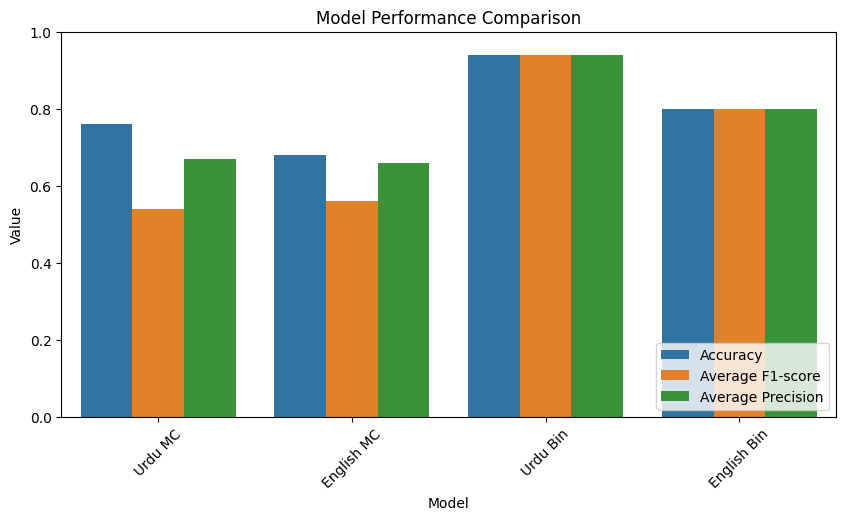

In [63]:
results = []

for name, (X_train, y_train, X_test, y_test) in tqdm(models.items()):
    model = SVC()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred)
    report["Model"] = name
    results.append(report)

df = pd.concat(results).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Model", y="Value", hue="Metric")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.xticks(rotation=45)
plt.title("Model Performance Comparison")
plt.show()

In [66]:
df

,Metric,Value,Model
0,Accuracy,0.76,Urdu MC
1,Average F1-score,0.54,Urdu MC
2,Average Precision,0.67,Urdu MC
3,Accuracy,0.68,English MC
4,Average F1-score,0.56,English MC
5,Average Precision,0.66,English MC
6,Accuracy,0.94,Urdu Bin
7,Average F1-score,0.94,Urdu Bin
8,Average Precision,0.94,Urdu Bin
9,Accuracy,0.80,English Bin


#### **AdaBoost**

100%|██████████| 4/4 [01:31<00:00, 22.80s/it]


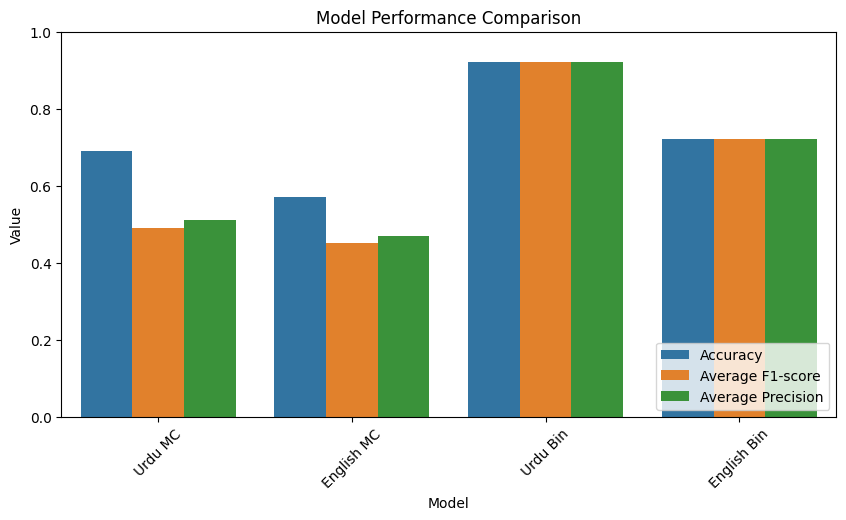

In [68]:
results = []

for name, (X_train, y_train, X_test, y_test) in tqdm(models.items()):
    model = AdaBoostClassifier()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred)
    report["Model"] = name
    results.append(report)

df = pd.concat(results).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Model", y="Value", hue="Metric")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.xticks(rotation=45)
plt.title("Model Performance Comparison")
plt.show()

In [69]:
df

,Metric,Value,Model
0,Accuracy,0.69,Urdu MC
1,Average F1-score,0.49,Urdu MC
2,Average Precision,0.51,Urdu MC
3,Accuracy,0.57,English MC
4,Average F1-score,0.45,English MC
5,Average Precision,0.47,English MC
6,Accuracy,0.92,Urdu Bin
7,Average F1-score,0.92,Urdu Bin
8,Average Precision,0.92,Urdu Bin
9,Accuracy,0.72,English Bin


#### **LightGBM**

  0%|          | 0/4 [00:00<?, ?it/s]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021922 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 4613, number of used features: 768
[LightGBM] [Info] Start training from score -1.427225
[LightGBM] [Info] Start training from score -0.640987
[LightGBM] [Info] Start training from score -2.634515
[LightGBM] [Info] Start training from score -1.823249


 25%|██▌       | 1/4 [00:21<01:04, 21.54s/it]

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 4541, number of used features: 768
[LightGBM] [Info] Start training from score -1.263167
[LightGBM] [Info] Start training from score -0.704442
[LightGBM] [Info] Start training from score -2.129333
[LightGBM] [Info] Start training from score -2.263924


 50%|█████     | 2/4 [00:44<00:44, 22.37s/it]

[LightGBM] [Info] Number of positive: 2430, number of negative: 2183
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021205 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 4613, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.526772 -> initscore=0.107191
[LightGBM] [Info] Start training from score 0.107191


 75%|███████▌  | 3/4 [00:50<00:14, 14.68s/it]

[LightGBM] [Info] Number of positive: 2245, number of negative: 2296
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020441 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 195840
[LightGBM] [Info] Number of data points in the train set: 4541, number of used features: 768
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.494384 -> initscore=-0.022463
[LightGBM] [Info] Start training from score -0.022463


100%|██████████| 4/4 [00:56<00:00, 14.03s/it]


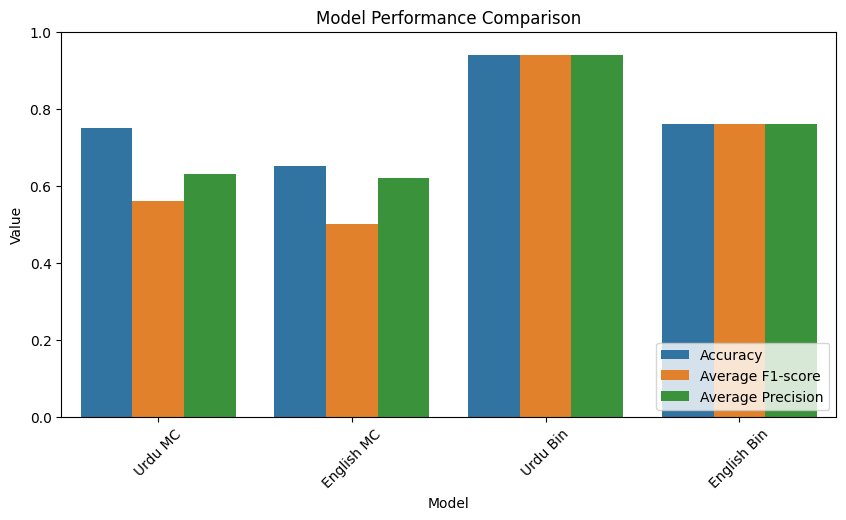

In [70]:
results = []

for name, (X_train, y_train, X_test, y_test) in tqdm(models.items()):
    model = lgb.LGBMClassifier()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    report = classification_report(y_test, y_pred)
    report["Model"] = name
    results.append(report)

df = pd.concat(results).reset_index(drop=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=df, x="Model", y="Value", hue="Metric")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.xticks(rotation=45)
plt.title("Model Performance Comparison")
plt.show()

In [71]:
df

,Metric,Value,Model
0,Accuracy,0.75,Urdu MC
1,Average F1-score,0.56,Urdu MC
2,Average Precision,0.63,Urdu MC
3,Accuracy,0.65,English MC
4,Average F1-score,0.50,English MC
5,Average Precision,0.62,English MC
6,Accuracy,0.94,Urdu Bin
7,Average F1-score,0.94,Urdu Bin
8,Average Precision,0.94,Urdu Bin
9,Accuracy,0.76,English Bin


In [73]:
df1 = pd.DataFrame({
    "Metric": ["Accuracy", "Average F1-score", "Average Precision"] * 4,
    "Value": [0.76, 0.54, 0.67, 0.68, 0.56, 0.66, 0.94, 0.94, 0.94, 0.80, 0.80, 0.80],
    "Model": ["Urdu MC"] * 3 + ["English MC"] * 3 + ["Urdu Bin"] * 3 + ["English Bin"] * 3
})

df2 = pd.DataFrame({
    "Metric": ["Accuracy", "Average F1-score", "Average Precision"] * 4,
    "Value": [0.69, 0.49, 0.51, 0.57, 0.45, 0.47, 0.92, 0.92, 0.92, 0.72, 0.72, 0.72],
    "Model": ["Urdu MC"] * 3 + ["English MC"] * 3 + ["Urdu Bin"] * 3 + ["English Bin"] * 3
})

df3 = pd.DataFrame({
    "Metric": ["Accuracy", "Average F1-score", "Average Precision"] * 4,
    "Value": [0.75, 0.56, 0.63, 0.65, 0.50, 0.62, 0.94, 0.94, 0.94, 0.76, 0.76, 0.76],
    "Model": ["Urdu MC"] * 3 + ["English MC"] * 3 + ["Urdu Bin"] * 3 + ["English Bin"] * 3
})

df = pd.concat([df1, df2, df3])
df = df.groupby(["Metric", "Model"], as_index=False).mean()
print(df)

               Metric        Model     Value
0            Accuracy  English Bin  0.760000
1            Accuracy   English MC  0.633333
2            Accuracy     Urdu Bin  0.933333
3            Accuracy      Urdu MC  0.733333
4    Average F1-score  English Bin  0.760000
5    Average F1-score   English MC  0.503333
6    Average F1-score     Urdu Bin  0.933333
7    Average F1-score      Urdu MC  0.530000
8   Average Precision  English Bin  0.760000
9   Average Precision   English MC  0.583333
10  Average Precision     Urdu Bin  0.933333
11  Average Precision      Urdu MC  0.603333
